<a href="https://colab.research.google.com/github/imnishu07/TensorFlow_Lite_Projects/blob/Thesis-Projects/Rnn%26LstmOptimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is specifically to optimize RNN, LSTM and Better LSTM, using Pruning and Quantization optimization Technique. The main aim is to get better results!

In [ ]:
'''
Setup: In essence, this cell is preparing your notebook with the tools,
You'll need for data handling, analysis, visualization, and potentially building machine learning models.
'''

import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

In [ ]:
!pip install tf_keras tensorflow-model-optimization --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 45.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
r

In [ ]:
import tf_keras        # drop-in replacement

In [ ]:
'''
This dataset contains 14 different features such as air temperature, atmospheric pressure, and humidity.
These were collected every 10 minutes, beginning in 2003
For efficiency, we will use only the data collected between 2009 and 2016.
'''

zip_path = tf_keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)
csv_path, _ = os.path.splitext(zip_path)

13568290/13568290 [==============================] - 0s 0us/step


In [ ]:
df = pd.read_csv(csv_path)
# Slice [start:stop:step], starting from index 5 take every 6th record.
df = df[5::6]

date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')
df.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
5,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
11,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
17,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
23,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
29,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


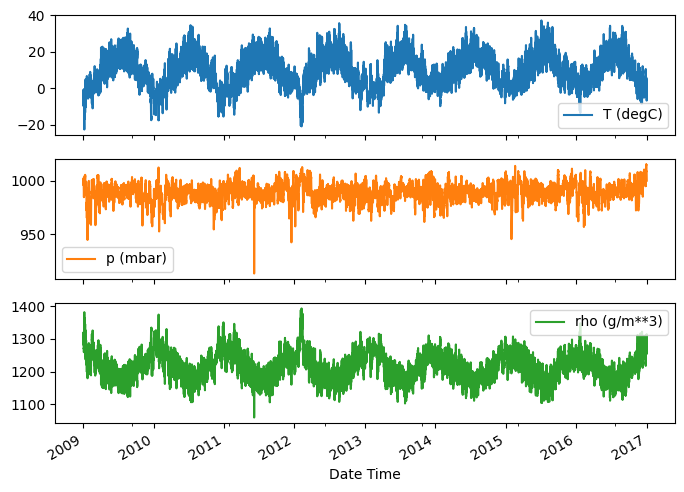

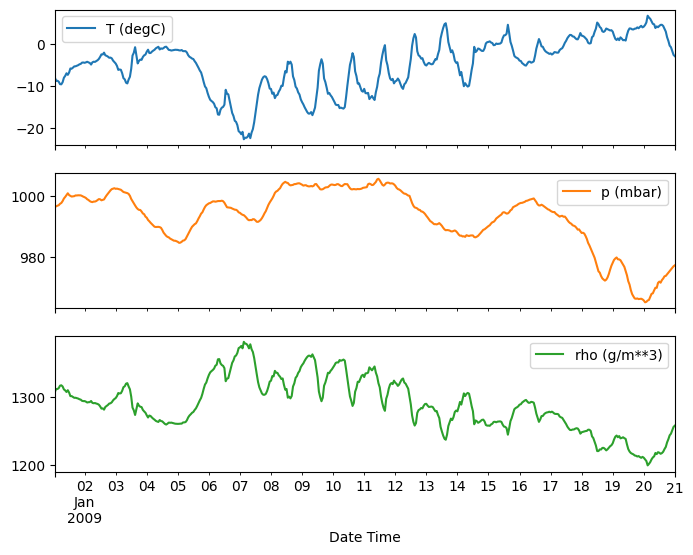

In [ ]:
#Here is the evolution of few features over time

plot_cols = ['T (degC)', 'p (mbar)', 'rho (g/m**3)']
plot_features = df[plot_cols]
plot_features.index = date_time
_ = plot_features.plot(subplots=True)

plot_features = df[plot_cols][:480]
plot_features.index = date_time[:480]
_ = plot_features.plot(subplots=True)

In [ ]:
#Inspect and cleanup
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.0,989.212842,8.358886,913.60,984.20,989.57,994.720,1015.29
T (degC),70091.0,9.450482,8.423384,-22.76,3.35,9.41,15.480,37.28
Tpot (K),70091.0,283.493086,8.504424,250.85,277.44,283.46,289.530,311.21
Tdew (degC),70091.0,4.956471,6.730081,-24.80,0.24,5.21,10.080,23.06
rh (%),70091.0,76.009788,16.474920,13.88,65.21,79.30,89.400,100.00
VPmax (mbar),70091.0,13.576576,7.739883,0.97,7.77,11.82,17.610,63.77
VPact (mbar),70091.0,9.533968,4.183658,0.81,6.22,8.86,12.360,28.25
VPdef (mbar),70091.0,4.042536,4.898549,0.00,0.87,2.19,5.300,46.01
sh (g/kg),70091.0,6.022560,2.655812,0.51,3.92,5.59,7.800,18.07
H2OC (mmol/mol),70091.0,9.640437,4.234862,0.81,6.29,8.96,12.490,28.74


In [ ]:
#There's a separate wind direction column, so the velocity should be greater than zero. Replace it with zeros

wv = df['wv (m/s)']
bad_wv = wv == -9999.0
wv[bad_wv] = 0.0

max_wv = df['max. wv (m/s)']
bad_max_wv = max_wv == -9999.0
max_wv[bad_max_wv] = 0.0

# The above inplace edits are reflected in the DataFrame.
df['wv (m/s)'].min()

0.0

(np.float64(-11.305513973134667),
 np.float64(8.24469928549079),
 np.float64(-8.27438540335515),
 np.float64(7.7338312955467785))

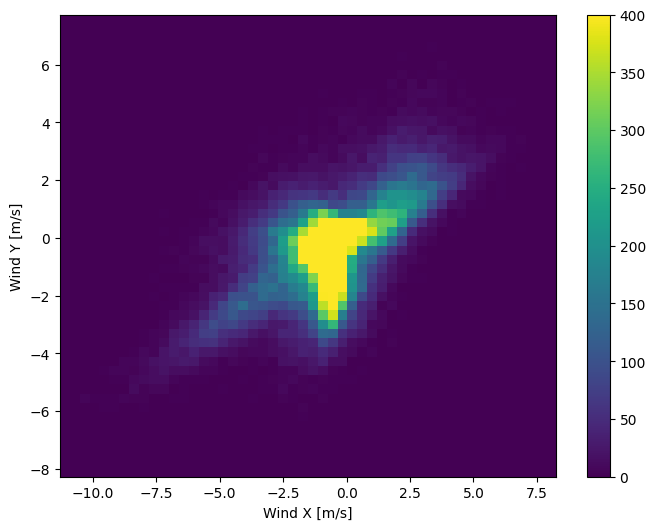

In [ ]:
#Let's convert the wind direction and velocity columns to a wind vector

wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')

# Convert to radians.
wd_rad = df.pop('wd (deg)')*np.pi / 180

# Calculate the wind x and y components.
df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)

# Calculate the max wind x and y components.
df['max Wx'] = max_wv*np.cos(wd_rad)
df['max Wy'] = max_wv*np.sin(wd_rad)

plt.hist2d(df['Wx'], df['Wy'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')

Text(0.5, 1.0, 'Time of day signal')

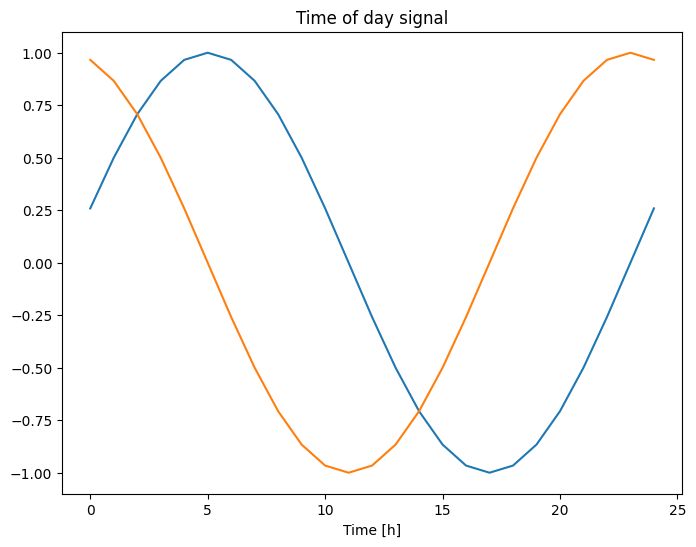

In [ ]:
#Similarly, converting the Date Time column to seconds
timestamp_s = date_time.map(pd.Timestamp.timestamp)

#Similarly, to deal with periodicity, we can get usable signals using sine and cosine transforms

day = 24*60*60
year = (365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

plt.plot(np.array(df['Day sin'])[:25])
plt.plot(np.array(df['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

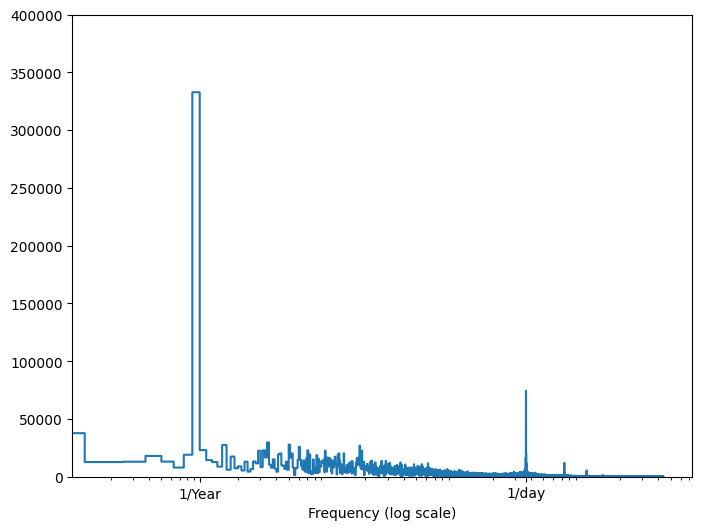

In [ ]:
fft = tf.signal.rfft(df['T (degC)'])
f_per_dataset = np.arange(0, len(fft))

n_samples_h = len(df['T (degC)'])
hours_per_year = 24*365.2524
years_per_dataset = n_samples_h/(hours_per_year)

f_per_year = f_per_dataset/years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale('log')
plt.ylim(0, 400000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1, 365.2524], labels=['1/Year', '1/day'])
_ = plt.xlabel('Frequency (log scale)')

In [ ]:
#Split the data

column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

In [ ]:
#Normalize the data

train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

/tmp/ipykernel_15727/3214313372.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(df.keys(), rotation=90)


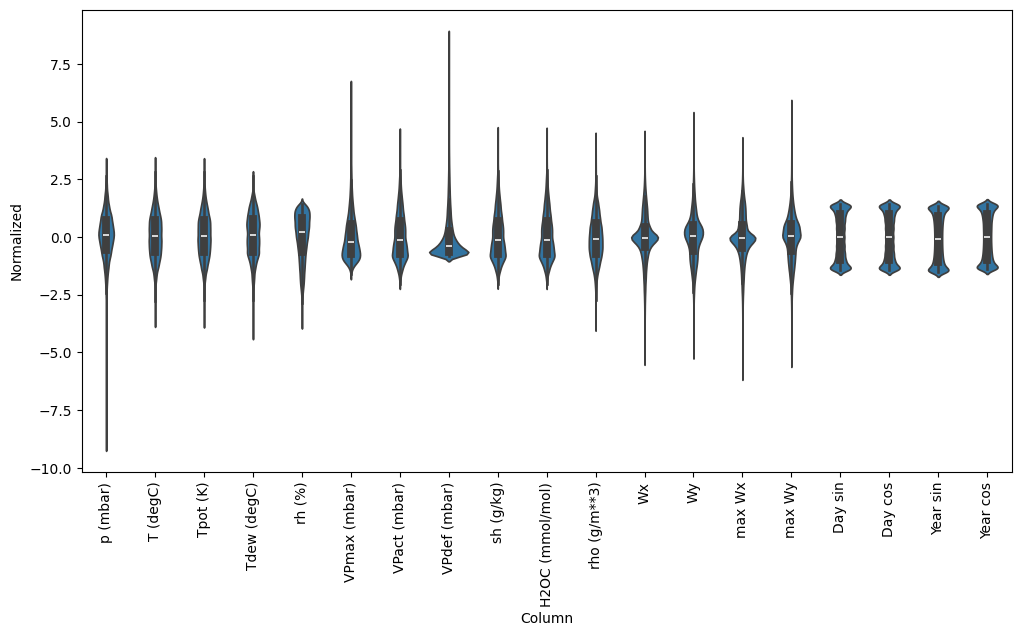

In [ ]:
df_std = (df - train_mean) / train_std
df_std = df_std.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(df.keys(), rotation=90)

In [ ]:
#Data Windowing

class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])

In [ ]:
w1 = WindowGenerator(input_width=24, label_width=1, shift=24,
                     label_columns=['T (degC)'])
w1

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['T (degC)']

In [ ]:
w2 = WindowGenerator(input_width=6,
                     label_width=1,
                     shift=1,
                     label_columns=['T (degC)'])
w2

Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['T (degC)']

In [ ]:
#Split: Split_window method will convert them to a window of inputs and a window of labels

def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

In [ ]:
# Stack three slices, the length of the total window.
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 19)
Inputs shape: (3, 6, 19)
Labels shape: (3, 1, 1)


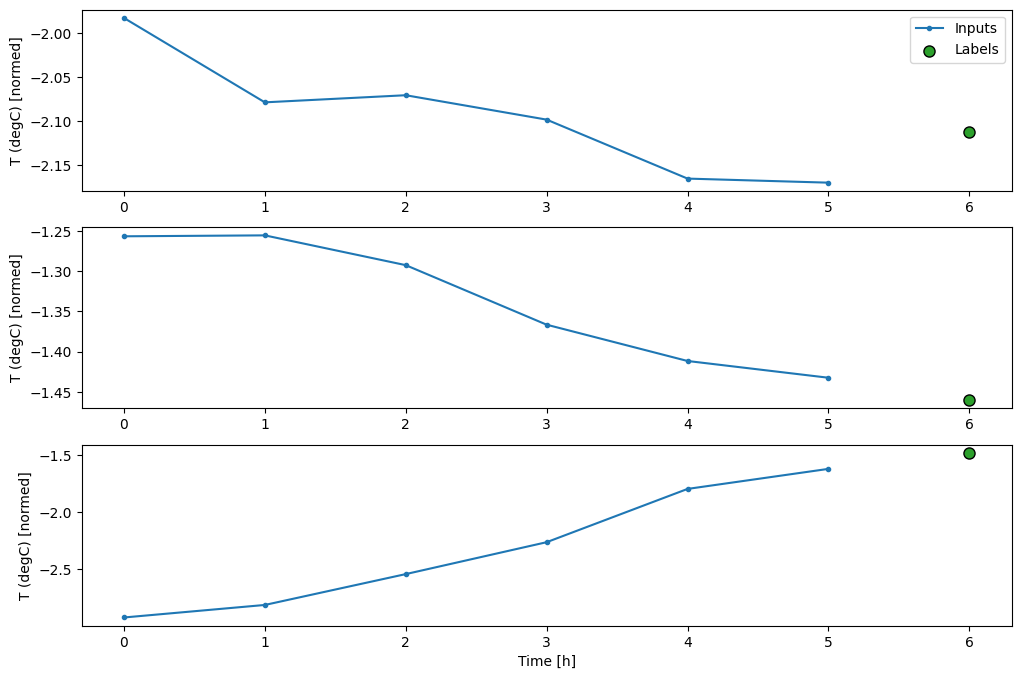

In [ ]:
#Plot: plot_method allows a simple visualization of the split window:

w2.example = example_inputs, example_labels

def plot(self, model=None, plot_col='T (degC)', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')
    plt.plot(self.input_indices, inputs[n, :, plot_col_index],
             label='Inputs', marker='.', zorder=-10)

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    plt.scatter(self.label_indices, labels[n, :, label_col_index],
                edgecolors='k', label='Labels', c='#2ca02c', s=64)
    if model is not None:
      predictions = model(inputs)
      plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                  marker='X', edgecolors='k', label='Predictions',
                  c='#ff7f0e', s=64)

    if n == 0:
      plt.legend()

  plt.xlabel('Time [h]')

WindowGenerator.plot = plot

w2.plot()

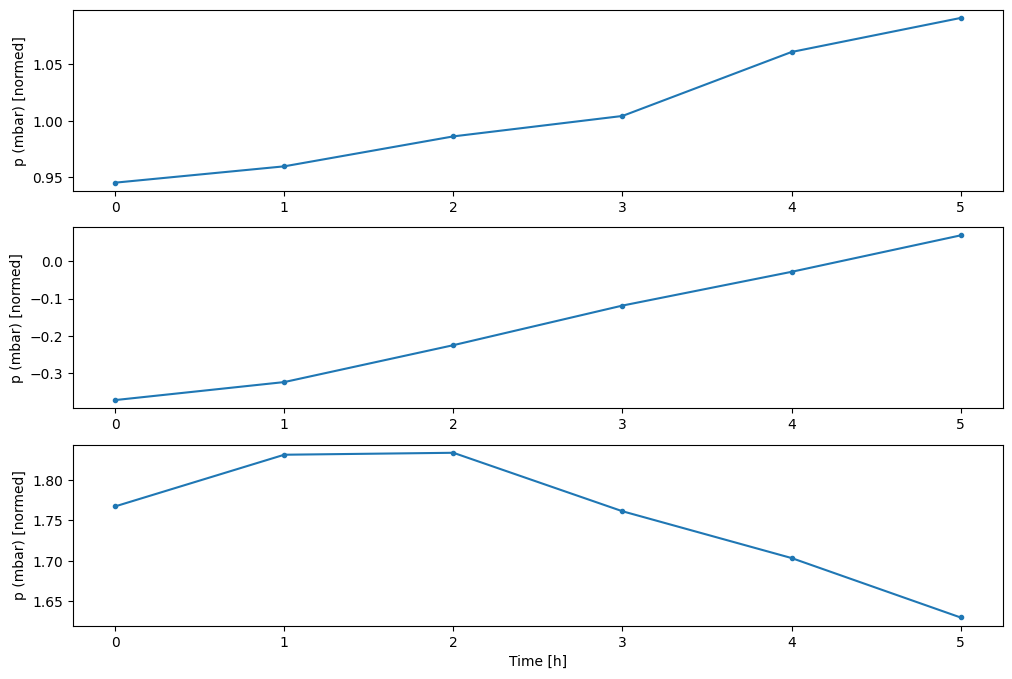

In [ ]:
#Similarly for other features

w2.plot(plot_col='p (mbar)')

In [ ]:
#Create tf.data.Datasets

def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf_keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

In [ ]:
#Since, the WindowGenerator object holds training, validation, and test data.
#Therefore, add properties for accessing and plotting them.

@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

In [ ]:
#Each element is an (inputs, label) pair
w2.train.element_spec

(TensorSpec(shape=(None, 6, 19), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1, 1), dtype=tf.float32, name=None))

In [ ]:
#Iterating over a Dataset yields concrete batches

for example_inputs, example_labels in w2.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 6, 19)
Labels shape (batch, time, features): (32, 1, 1)


In [ ]:
#Start by building models to predict the T(degC) value one hour into the future

#Configure a WG object to produce these single-step pairs
single_step_window = WindowGenerator(
    input_width=1, label_width=1, shift=1,
    label_columns=['T (degC)'])
single_step_window

Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['T (degC)']

In [ ]:
for example_inputs, example_labels in single_step_window.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 1, 19)
Labels shape (batch, time, features): (32, 1, 1)


In [ ]:
#Creating a performance baseline as a point of comparison with the later more complicated models

class Baseline(tf_keras.Model):
  def __init__(self, label_index=None):
    super().__init__()
    self.label_index = label_index

  def call(self, inputs):
    if self.label_index is None:
      return inputs
    result = inputs[:, :, self.label_index]
    return result[:, :, tf.newaxis]

baseline = Baseline(label_index=column_indices['T (degC)'])

baseline.compile(loss=tf_keras.losses.MeanSquaredError(),
                 metrics=[tf_keras.metrics.MeanAbsoluteError()])

val_performance = {}
performance = {}
val_performance['Baseline'] = baseline.evaluate(single_step_window.val, return_dict=True)
performance['Baseline'] = baseline.evaluate(single_step_window.test, verbose=0, return_dict=True)

439/439 [==============================] - 3s 6ms/step - loss: 0.0128 - mean_absolute_error: 0.0785


In [ ]:
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1,
    label_columns=['T (degC)'])

wide_window

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['T (degC)']

In [ ]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', baseline(wide_window.example[0]).shape)

Input shape: (32, 24, 19)
Output shape: (32, 24, 1)


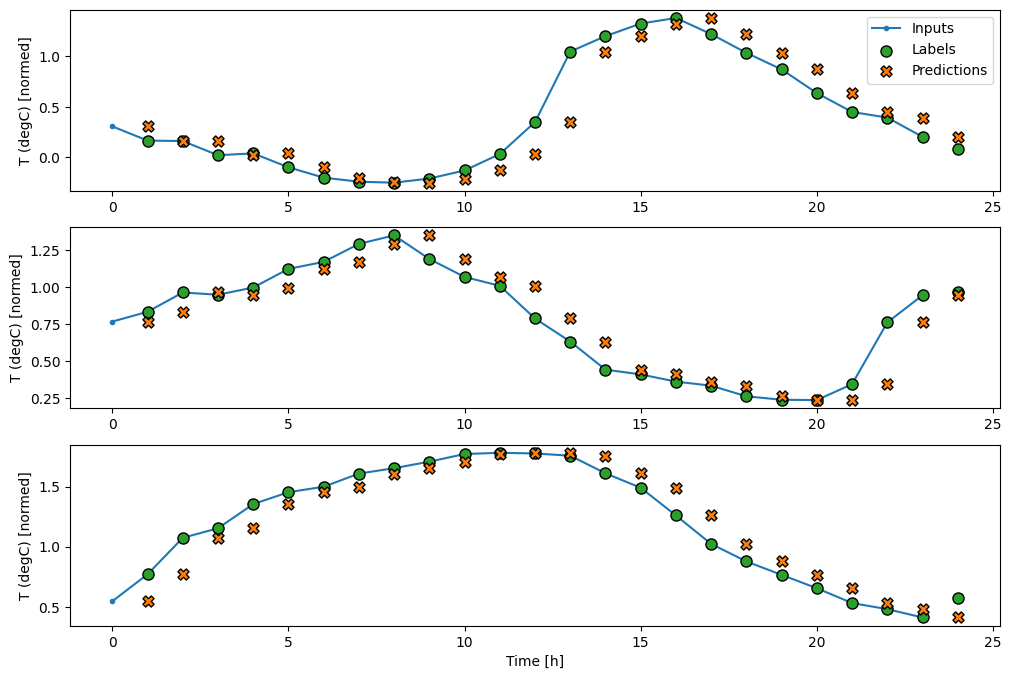

In [ ]:
wide_window.plot(baseline)

In [ ]:
#Training a basic and most simple linear model

linear = tf_keras.Sequential([
    tf_keras.layers.Dense(units=1)
])

print('Input shape:', single_step_window.example[0].shape)
print('Output shape:', linear(single_step_window.example[0]).shape)

Input shape: (32, 1, 19)
Output shape: (32, 1, 1)


In [ ]:
#We will be training many models, therefore let's package the training procedure into a function:

MAX_EPOCHS = 20

def compile_and_fit(model, window, patience=2, callbacks=None):
  early_stopping = tf_keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  if callbacks is None:
      callbacks = []
  callbacks.append(early_stopping)

  model.compile(loss=tf_keras.losses.MeanSquaredError(),
                optimizer=tf_keras.optimizers.Adam(),
                metrics=[tf_keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=callbacks)
  return history

First, a basic RNN model, considering unroll attribute as True and adding an explicit Input layer to correctly interpret input shape.

In [ ]:
NUM_FEATURES = train_df.shape[1]  # confirm this is 24

rnn_model = tf_keras.models.Sequential([
    tf_keras.layers.Input(shape=(wide_window.input_width, NUM_FEATURES)),
    tf_keras.layers.SimpleRNN(32, unroll=True, return_sequences=True),
    tf_keras.layers.Dense(units=1)
])

rnn_model.summary()
# Look for: (None, input_width, 32) after SimpleRNN
#           (None, input_width, 1)  after Dense

print('Input shape:', wide_window.example[0].shape)
print('Output shape:', rnn_model(wide_window.example[0]).shape)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 24, 32)            1664      
                                                                 
 dense_1 (Dense)             (None, 24, 1)             33        
                                                                 
Total params: 1697 (6.63 KB)
Trainable params: 1697 (6.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Input shape: (32, 24, 19)
Output shape: (32, 24, 1)


In [ ]:
history = compile_and_fit(rnn_model, wide_window)

IPython.display.clear_output()
val_performance['RNN'] = rnn_model.evaluate(wide_window.val, return_dict=True)
performance['RNN'] = rnn_model.evaluate(wide_window.test, verbose=0, return_dict=True)

# Convert the RNN model to a TensorFlow Lite model
converter = tf.lite.TFLiteConverter.from_keras_model(rnn_model)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_model_rnn = converter.convert()

# Save the TensorFlow Lite model
tflite_model_path_rnn = 'rnn_model.tflite'
with open(tflite_model_path_rnn, 'wb') as f:
  f.write(tflite_model_rnn)

print(f'Model "RNN" converted to TFLite and saved as "{tflite_model_path_rnn}"')

print('\nValidation Performance for RNN Model:')
print(val_performance.get('RNN'))

print('\nTest Performance for RNN Model:')
print(performance.get('RNN'))

438/438 [==============================] - 2s 5ms/step - loss: 0.0059 - mean_absolute_error: 0.0531
Model "RNN" converted to TFLite and saved as "rnn_model.tflite"

Validation Performance for RNN Model:
{'loss': 0.005868594162166119, 'mean_absolute_error': 0.05306537449359894}

Test Performance for RNN Model:
{'loss': 0.005845094099640846, 'mean_absolute_error': 0.054125044494867325}


Since, X-Cube-AI doesn't benefit from unstructured weight sparsity at the hardware level. Therefore, we will use structured Pruning where neurons/filters are removed and FLASH and MACC is heavily impacted.

In [ ]:
import tensorflow_model_optimization as tfmot
import tensorflow as tf

# ─── Step 1: Structured pruning via smaller architecture ──────────────────────
# True structured pruning = rebuild with fewer units, not magnitude zeroing.
# Original: SimpleRNN(32) → Structured pruned: SimpleRNN(16)

NUM_FEATURES = train_df.shape[1]
INPUT_WIDTH  = wide_window.input_width

pruned_rnn_model = tf_keras.models.Sequential([
    tf_keras.layers.Input(shape=(INPUT_WIDTH, NUM_FEATURES)),
    tf_keras.layers.SimpleRNN(16, unroll=True, return_sequences=True),  # 32→16: true structure reduction
    tf_keras.layers.Dense(units=1)
])

pruned_rnn_model.summary()

# ─── Step 2: Train the smaller model ─────────────────────────────────────────
history_pruned = compile_and_fit(pruned_rnn_model, wide_window)

IPython.display.clear_output()

val_performance['RNN_Pruned'] = pruned_rnn_model.evaluate(
    wide_window.val, return_dict=True
)
performance['RNN_Pruned'] = pruned_rnn_model.evaluate(
    wide_window.test, verbose=0, return_dict=True
)

print('Validation:', val_performance['RNN_Pruned'])
print('Test:      ', performance['RNN_Pruned'])

# ─── Step 3: Convert to TFLite CORRECTLY for X-CUBE-AI ───────────────────────

# Lock batch=1 for MCU inference — critical for X-CUBE-AI shape inference
@tf.function(input_signature=[
    tf.TensorSpec(shape=[1, INPUT_WIDTH, NUM_FEATURES], dtype=tf.float32)
])
def serving_fn(x):
    return pruned_rnn_model(x)

# Option A — Float32 (baseline, no quantization)
converter_f32 = tf.lite.TFLiteConverter.from_concrete_functions(
    [serving_fn.get_concrete_function()]
)
# ONLY builtins — no SELECT_TF_OPS, no Flex ops
converter_f32.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
tflite_f32 = converter_f32.convert()

with open('rnn_model_pruned_f32.tflite', 'wb') as f:
    f.write(tflite_f32)
print(f'Float32 model saved — size: {len(tflite_f32)/1024:.1f} KB')


438/438 [==============================] - 2s 5ms/step - loss: 0.0060 - mean_absolute_error: 0.0533
Validation: {'loss': 0.00597362732514739, 'mean_absolute_error': 0.05330002307891846}
Test:       {'loss': 0.005897799506783485, 'mean_absolute_error': 0.05371681600809097}


Float32 model saved — size: 22.3 KB


Now that pruning is done on rnn_model, lets shift to quantization technique and understand it working.

In [ ]:
# Option B — INT8 Quantized (use THIS one for X-CUBE-AI for real FLASH/RAM reduction)
converter_int8 = tf.lite.TFLiteConverter.from_concrete_functions(
    [serving_fn.get_concrete_function()]
)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset():
    for batch in wide_window.train.take(100):
        inputs, _ = batch
        # Ensure batch=1 slicing matches locked input shape
        for i in range(min(tf.shape(inputs)[0].numpy(), 32)):
            yield [tf.expand_dims(tf.cast(inputs[i], tf.float32), axis=0)]

converter_int8.representative_dataset   = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type     = tf.int8
converter_int8.inference_output_type    = tf.int8

tflite_int8 = converter_int8.convert()

with open('rnn_model_pruned_int8.tflite', 'wb') as f:
    f.write(tflite_int8)
print(f'INT8 model saved  — size: {len(tflite_int8)/1024:.1f} KB')

# ─── Step 4: Verify tensor shapes — confirm no dim=24 ────────────────────────
print('\nTensor shapes (INT8 model):')
interpreter = tf.lite.Interpreter(model_content=tflite_int8)
interpreter.allocate_tensors()
for t in interpreter.get_tensor_details():
    print(f"  [{t['index']:3d}] {t['name']:45s} {list(t['shape'])}")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 model saved  — size: 55.1 KB

Tensor shapes (INT8 model):
  [  0] x                                             [np.int32(1), np.int32(24), np.int32(19)]
  [  1] arith.constant                                [np.int32(3)]
  [  2] arith.constant1                               [np.int32(3)]
  [  3] tfl.pseudo_qconst                             [np.int32(1)]
  [  4] tfl.pseudo_qconst1                            [np.int32(1), np.int32(16)]
  [  5] tfl.pseudo_qconst2                            [np.int32(16), np.int32(16)]
  [  6] tfl.pseudo_qconst3                            [np.int32(16)]
  [  7] tfl.pseudo_qconst4                            [np.int32(16)]
  [  8] tfl.pseudo_qconst5                            [np.int32(16)]
  [  9] tfl.pseudo_qconst6                            [np.int32(16)]
  [ 10] tfl.pseudo_qconst7                            [np.int32(16)]
  [ 11] tfl.pseudo_qconst8                            [np.int32(16)]
  [ 12] tfl.pseudo_qconst9                            [np.

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Our second model is a single-layer LSTM

In [ ]:
lstm_model = tf_keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf_keras.layers.LSTM(32, unroll= True, return_sequences=True),
    # Shape => [batch, time, features]
    tf_keras.layers.Dense(units=1)
])

In [ ]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', lstm_model(wide_window.example[0]).shape)

Input shape: (32, 24, 19)
Output shape: (32, 24, 1)


In [ ]:
history = compile_and_fit(lstm_model, wide_window)

IPython.display.clear_output()
val_performance['LSTM'] = lstm_model.evaluate(wide_window.val, return_dict=True)
performance['LSTM'] = lstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)

# Convert the LSTM model to a TensorFlow Lite model
converter = tf.lite.TFLiteConverter.from_keras_model(lstm_model)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_model_lstm = converter.convert()

# Save the TensorFlow Lite model
tflite_model_path_lstm = 'lstm_model.tflite'
with open(tflite_model_path_lstm, 'wb') as f:
  f.write(tflite_model_lstm)

print(f'Model "LSTM" converted to TFLite and saved as "{tflite_model_path_lstm}"')

print('\nValidation Performance for LSTM Model:')
print(val_performance.get('LSTM'))

print('\nTest Performance for LSTM Model:')
print(performance.get('LSTM'))

438/438 [==============================] - 6s 14ms/step - loss: 0.0055 - mean_absolute_error: 0.0511
Model "LSTM" converted to TFLite and saved as "lstm_model.tflite"

Validation Performance for LSTM Model:
{'loss': 0.005547537934035063, 'mean_absolute_error': 0.05106009542942047}

Test Performance for LSTM Model:
{'loss': 0.005573269445449114, 'mean_absolute_error': 0.05220719799399376}


In [ ]:
import tensorflow_model_optimization as tfmot
import tensorflow as tf

# ─── Step 1: Structured Pruning = Rebuild With Fewer Units ───────────────────
# Original:         LSTM(32) → Dense(1)
# Structured pruned: LSTM(16) → Dense(1)  ← half the units, real MACC/FLASH reduction

NUM_FEATURES = train_df.shape[1]   # confirm this is 24 (or whatever your feature count is)
INPUT_WIDTH  = wide_window.input_width

pruned_lstm_model = tf_keras.models.Sequential([
    tf_keras.layers.Input(shape=(INPUT_WIDTH, NUM_FEATURES)),
    tf_keras.layers.LSTM(
        16,                      # 32 → 16: true structural reduction
        unroll=True,             # required for X-CUBE-AI (no WHILE/FlexOps)
        return_sequences=True    # keep same output shape as original
    ),
    tf_keras.layers.Dense(units=1)
])

print("=== Structured Pruned LSTM Summary ===")
pruned_lstm_model.summary()

# Quick MACC estimate so you can compare before/after in X-CUBE-AI
original_lstm_params  = 32 * (NUM_FEATURES + 32 + 1) * 4   # 4 gates
pruned_lstm_params    = 16 * (NUM_FEATURES + 16 + 1) * 4
print(f'\nOriginal LSTM params (approx): {original_lstm_params:,}')
print(f'Pruned   LSTM params (approx): {pruned_lstm_params:,}')
print(f'Reduction ratio: {original_lstm_params / pruned_lstm_params:.1f}x')

# ─── Step 2: Train the Smaller Model ─────────────────────────────────────────
print('\n=== Training Pruned LSTM ===')
history_pruned_lstm = compile_and_fit(pruned_lstm_model, wide_window)

IPython.display.clear_output()

val_performance['LSTM_Pruned'] = pruned_lstm_model.evaluate(
    wide_window.val, return_dict=True
)
performance['LSTM_Pruned'] = pruned_lstm_model.evaluate(
    wide_window.test, verbose=0, return_dict=True
)

print('Validation:', val_performance['LSTM_Pruned'])
print('Test:      ', performance['LSTM_Pruned'])

# Compare against original LSTM
print('\n=== Performance Comparison ===')
print(f"Original LSTM  val MAE: {val_performance['LSTM']['mean_absolute_error']:.4f}")
print(f"Pruned   LSTM  val MAE: {val_performance['LSTM_Pruned']['mean_absolute_error']:.4f}")

# ─── Step 3: Lock Input Shape + Export ───────────────────────────────────────
# batch=1 is mandatory — X-CUBE-AI requires a fixed, known batch dimension

@tf.function(input_signature=[
    tf.TensorSpec(shape=[1, INPUT_WIDTH, NUM_FEATURES], dtype=tf.float32)
])
def serving_fn_lstm(x):
    return pruned_lstm_model(x)

concrete_fn = serving_fn_lstm.get_concrete_function()

# ── Option A: Float32 (for baseline comparison in X-CUBE-AI) ─────────────────
converter_f32 = tf.lite.TFLiteConverter.from_concrete_functions([concrete_fn])
converter_f32.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS    # NO SELECT_TF_OPS — avoids FlexOps
]
tflite_lstm_f32 = converter_f32.convert()

with open('lstm_model_pruned_f32.tflite', 'wb') as f:
    f.write(tflite_lstm_f32)
print(f'\nFloat32 saved — size: {len(tflite_lstm_f32)/1024:.1f} KB')

438/438 [==============================] - 2s 5ms/step - loss: 0.0056 - mean_absolute_error: 0.0520
Validation: {'loss': 0.005643501877784729, 'mean_absolute_error': 0.052029211074113846}
Test:       {'loss': 0.005665677599608898, 'mean_absolute_error': 0.0531921349465847}

=== Performance Comparison ===
Original LSTM  val MAE: 0.0511
Pruned   LSTM  val MAE: 0.0520



Float32 saved — size: 66.7 KB


Now that pruning is done with LSTM_model, let's focus on quantizing this model.

In [ ]:
# ── Option B: INT8 Quantized (use THIS in X-CUBE-AI for max FLASH/RAM savings)
converter_int8 = tf.lite.TFLiteConverter.from_concrete_functions([concrete_fn])
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset_lstm():
    for batch in wide_window.train.take(100):
        inputs, _ = batch
        for i in range(min(tf.shape(inputs)[0].numpy(), 32)):
            yield [tf.expand_dims(tf.cast(inputs[i], tf.float32), axis=0)]

converter_int8.representative_dataset    = representative_dataset_lstm
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type      = tf.int8
converter_int8.inference_output_type     = tf.int8

tflite_lstm_int8 = converter_int8.convert()

with open('lstm_model_pruned_int8.tflite', 'wb') as f:
    f.write(tflite_lstm_int8)
print(f'INT8    saved — size: {len(tflite_lstm_int8)/1024:.1f} KB')
print(f'Size reduction from quantization: {len(tflite_lstm_f32)/len(tflite_lstm_int8):.1f}x')

# ─── Step 4: Verify Tensor Shapes ────────────────────────────────────────────
# Confirm no rogue dim=24 or unexpected shapes before loading into X-CUBE-AI

print('\n=== Tensor shapes (INT8 model) ===')
interpreter = tf.lite.Interpreter(model_content=tflite_lstm_int8)
interpreter.allocate_tensors()

for t in interpreter.get_tensor_details():
    shape = list(t['shape'])
    flag  = ' ⚠️  CHECK THIS' if 24 in shape else ''
    print(f"  [{t['index']:3d}] {t['name']:50s} {shape}{flag}")

# ─── Step 5: Sanity Check — Run One Inference ────────────────────────────────
# Catches shape/type errors before you load into STM32CubeIDE

print('\n=== Inference Sanity Check ===')
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Grab one real sample from validation set
for batch in wide_window.val.take(1):
    sample_input, sample_label = batch

sample = tf.expand_dims(tf.cast(sample_input[0], tf.float32), axis=0)  # shape [1, INPUT_WIDTH, NUM_FEATURES]

# INT8 models expect scaled int8 input
input_scale, input_zero_point = input_details[0]['quantization']
sample_int8 = (sample.numpy() / input_scale + input_zero_point).astype('int8')

interpreter.set_tensor(input_details[0]['index'], sample_int8)
interpreter.invoke()

output_int8 = interpreter.get_tensor(output_details[0]['index'])
output_scale, output_zero_point = output_details[0]['quantization']
output_f32  = (output_int8.astype('float32') - output_zero_point) * output_scale

print(f'Input  shape : {sample_int8.shape}')
print(f'Output shape : {output_f32.shape}')
print(f'Sample output: {output_f32.flatten()[:5]}')
print(f'Sample label : {sample_label[0].numpy().flatten()[:5]}')
print('\n✅ Model ready for X-CUBE-AI — use lstm_model_pruned_int8.tflite')

INT8    saved — size: 104.4 KB
Size reduction from quantization: 0.6x

=== Tensor shapes (INT8 model) ===
  [  0] x                                                  [np.int32(1), np.int32(24), np.int32(19)] ⚠️  CHECK THIS
  [  1] arith.constant                                     [np.int32(3)]
  [  2] arith.constant1                                    []
  [  3] arith.constant2                                    [np.int32(3)]
  [  4] tfl.pseudo_qconst                                  [np.int32(1)]
  [  5] tfl.pseudo_qconst1                                 [np.int32(1), np.int32(16)]
  [  6] tfl.pseudo_qconst2                                 [np.int32(64), np.int32(16)]
  [  7] tfl.pseudo_qconst3                                 [np.int32(64)]
  [  8] tfl.pseudo_qconst4                                 [np.int32(64)]
  [  9] tfl.pseudo_qconst5                                 [np.int32(64), np.int32(19)]
  [ 10] sequential_6/lstm_3/transpose1                     [np.int32(24), np.int32(1),

Third model, a stacked LSTM with two layers

In [ ]:
better_lstm_model = tf_keras.models.Sequential([
    tf_keras.layers.LSTM(16, unroll=True, return_sequences=True), # First LSTM layer returns sequences
    tf_keras.layers.LSTM(8, unroll=True, return_sequences=False), # Second LSTM layer processes the sequences
    tf_keras.layers.Dense(units=1)
])

print('Input shape:', wide_window.example[0].shape)
print('Output shape:', better_lstm_model(wide_window.example[0]).shape)

Input shape: (32, 24, 19)
Output shape: (32, 1)


In [ ]:
history_better_lstm = compile_and_fit(better_lstm_model, wide_window)

IPython.display.clear_output()
val_performance['Better LSTM'] = better_lstm_model.evaluate(wide_window.val, return_dict=True)
performance['Better LSTM'] = better_lstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)

# Convert the Better LSTM model to a TensorFlow Lite model
converter = tf.lite.TFLiteConverter.from_keras_model(better_lstm_model)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_model_better_lstm = converter.convert()

# Save the TensorFlow Lite model
tflite_model_path_better_lstm = 'better_lstm_model.tflite'
with open(tflite_model_path_better_lstm, 'wb') as f:
  f.write(tflite_model_better_lstm)

print(f'Model "Better LSTM" converted to TFLite and saved as "{tflite_model_path_better_lstm}"')

print('\nValidation Performance for Better LSTM Model:')
print(val_performance.get('Better LSTM'))

print('\nTest Performance for Better LSTM Model:')
print(performance.get('Better LSTM'))

438/438 [==============================] - 3s 7ms/step - loss: 0.1114 - mean_absolute_error: 0.2543
Model "Better LSTM" converted to TFLite and saved as "better_lstm_model.tflite"

Validation Performance for Better LSTM Model:
{'loss': 0.11138232052326202, 'mean_absolute_error': 0.25429418683052063}

Test Performance for Better LSTM Model:
{'loss': 0.12934085726737976, 'mean_absolute_error': 0.28221914172172546}


In [ ]:
import tensorflow_model_optimization as tfmot
import tensorflow as tf

# ─── Step 1: Structured Pruning = Rebuild With Fewer Units ───────────────────
# Original:          LSTM(16) → LSTM(8) → Dense(1)
# Structured pruned: LSTM(8)  → LSTM(4) → Dense(1)  ← half units per layer

NUM_FEATURES = train_df.shape[1]
INPUT_WIDTH  = wide_window.input_width

pruned_better_lstm_model = tf_keras.models.Sequential([
    tf_keras.layers.Input(shape=(INPUT_WIDTH, NUM_FEATURES)),
    tf_keras.layers.LSTM(
        8,                       # 16 → 8: structural reduction layer 1
        unroll=True,             # required for X-CUBE-AI
        return_sequences=True    # must be True to feed into second LSTM
    ),
    tf_keras.layers.LSTM(
        4,                       # 8 → 4: structural reduction layer 2
        unroll=True,
        return_sequences=False   # final LSTM — collapses time dimension
    ),
    tf_keras.layers.Dense(units=1)
])

print("=== Structured Pruned Better LSTM Summary ===")
pruned_better_lstm_model.summary()

# MACC estimate for comparison
def estimate_lstm_params(units, input_dim):
    return units * (input_dim + units + 1) * 4  # 4 gates

original_l1 = estimate_lstm_params(16, NUM_FEATURES)
original_l2 = estimate_lstm_params(8,  16)           # input_dim = prev units
pruned_l1   = estimate_lstm_params(8,  NUM_FEATURES)
pruned_l2   = estimate_lstm_params(4,  8)

print(f'\nLayer-wise param comparison:')
print(f'  Layer 1 — Original: {original_l1:,}  →  Pruned: {pruned_l1:,}  ({original_l1/pruned_l1:.1f}x smaller)')
print(f'  Layer 2 — Original: {original_l2:,}  →  Pruned: {pruned_l2:,}  ({original_l2/pruned_l2:.1f}x smaller)')
print(f'  Total   — Original: {original_l1+original_l2:,}  →  Pruned: {pruned_l1+pruned_l2:,}  ({(original_l1+original_l2)/(pruned_l1+pruned_l2):.1f}x smaller)')

# ─── Step 2: Train the Smaller Model ─────────────────────────────────────────
print('\n=== Training Pruned Better LSTM ===')
history_pruned_better_lstm = compile_and_fit(pruned_better_lstm_model, wide_window)

IPython.display.clear_output()

val_performance['Better_LSTM_Pruned'] = pruned_better_lstm_model.evaluate(
    wide_window.val, return_dict=True
)
performance['Better_LSTM_Pruned'] = pruned_better_lstm_model.evaluate(
    wide_window.test, verbose=0, return_dict=True
)

print('Validation:', val_performance['Better_LSTM_Pruned'])
print('Test:      ', performance['Better_LSTM_Pruned'])

# Compare against original
print('\n=== Performance Comparison ===')
print(f"Original Better LSTM  val MAE: {val_performance['Better LSTM']['mean_absolute_error']:.4f}")
print(f"Pruned   Better LSTM  val MAE: {val_performance['Better_LSTM_Pruned']['mean_absolute_error']:.4f}")

# ─── Step 3: Lock Input Shape + Export ───────────────────────────────────────
@tf.function(input_signature=[
    tf.TensorSpec(shape=[1, INPUT_WIDTH, NUM_FEATURES], dtype=tf.float32)
])
def serving_fn_better_lstm(x):
    return pruned_better_lstm_model(x)

concrete_fn = serving_fn_better_lstm.get_concrete_function()

# ── Option A: Float32 ────────────────────────────────────────────────────────
converter_f32 = tf.lite.TFLiteConverter.from_concrete_functions([concrete_fn])
converter_f32.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS    # NO SELECT_TF_OPS
]
tflite_better_lstm_f32 = converter_f32.convert()

with open('better_lstm_pruned_f32.tflite', 'wb') as f:
    f.write(tflite_better_lstm_f32)
print(f'\nFloat32 saved — size: {len(tflite_better_lstm_f32)/1024:.1f} KB')

438/438 [==============================] - 3s 7ms/step - loss: 0.1115 - mean_absolute_error: 0.2541
Validation: {'loss': 0.11145736277103424, 'mean_absolute_error': 0.25406932830810547}
Test:       {'loss': 0.12944495677947998, 'mean_absolute_error': 0.2822636663913727}

=== Performance Comparison ===
Original Better LSTM  val MAE: 0.2543
Pruned   Better LSTM  val MAE: 0.2541



Float32 saved — size: 117.6 KB


In [ ]:
# ── Option B: INT8 Quantized ─────────────────────────────────────────────────
converter_int8 = tf.lite.TFLiteConverter.from_concrete_functions([concrete_fn])
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset_better_lstm():
    for batch in wide_window.train.take(100):
        inputs, _ = batch
        for i in range(min(tf.shape(inputs)[0].numpy(), 32)):
            yield [tf.expand_dims(tf.cast(inputs[i], tf.float32), axis=0)]

converter_int8.representative_dataset    = representative_dataset_better_lstm
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type      = tf.int8
converter_int8.inference_output_type     = tf.int8

tflite_better_lstm_int8 = converter_int8.convert()

with open('better_lstm_pruned_int8.tflite', 'wb') as f:
    f.write(tflite_better_lstm_int8)
print(f'INT8    saved — size: {len(tflite_better_lstm_int8)/1024:.1f} KB')
print(f'Size reduction from quantization: {len(tflite_better_lstm_f32)/len(tflite_better_lstm_int8):.1f}x')

# ─── Step 4: Verify Tensor Shapes ────────────────────────────────────────────
print('\n=== Tensor shapes (INT8 model) ===')
interpreter = tf.lite.Interpreter(model_content=tflite_better_lstm_int8)
interpreter.allocate_tensors()

for t in interpreter.get_tensor_details():
    shape = list(t['shape'])
    flag  = ' ⚠️  CHECK THIS' if any(d in shape for d in [24, 48]) else ''
    print(f"  [{t['index']:3d}] {t['name']:50s} {shape}{flag}")

# ─── Step 5: Sanity Check — Run One Inference ────────────────────────────────
print('\n=== Inference Sanity Check ===')
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

for batch in wide_window.val.take(1):
    sample_input, sample_label = batch

sample = tf.expand_dims(tf.cast(sample_input[0], tf.float32), axis=0)

input_scale, input_zero_point = input_details[0]['quantization']
sample_int8 = (sample.numpy() / input_scale + input_zero_point).astype('int8')

interpreter.set_tensor(input_details[0]['index'], sample_int8)
interpreter.invoke()

output_int8 = interpreter.get_tensor(output_details[0]['index'])
output_scale, output_zero_point = output_details[0]['quantization']
output_f32  = (output_int8.astype('float32') - output_zero_point) * output_scale

print(f'Input  shape : {sample_int8.shape}')
print(f'Output shape : {output_f32.shape}')
print(f'Sample output: {output_f32.flatten()[:5]}')
print(f'Sample label : {sample_label[0].numpy().flatten()[:5]}')
print('\n✅ Model ready for X-CUBE-AI — use better_lstm_pruned_int8.tflite')

# ─── Step 6: Full Model Comparison Summary ───────────────────────────────────
print('\n' + '='*60)
print('FULL MODEL COMPARISON SUMMARY')
print('='*60)

models_summary = {
    'RNN          (original)': ('rnn_model',         val_performance.get('RNN')),
    'RNN          (pruned)  ': ('rnn_pruned',         val_performance.get('RNN_Pruned')),
    'LSTM         (original)': ('lstm_model',         val_performance.get('LSTM')),
    'LSTM         (pruned)  ': ('lstm_pruned',         val_performance.get('LSTM_Pruned')),
    'Better LSTM  (original)': ('better_lstm_model',  val_performance.get('Better LSTM')),
    'Better LSTM  (pruned)  ': ('better_lstm_pruned', val_performance.get('Better_LSTM_Pruned')),
}

print(f'\n{"Model":<30} {"Val MAE":>10}')
print('-' * 42)
for name, (_, perf) in models_summary.items():
    if perf:
        mae = perf.get('mean_absolute_error', float('nan'))
        print(f'{name:<30} {mae:>10.4f}')

print('\nFiles saved for X-CUBE-AI:')
print('  📦 better_lstm_pruned_int8.tflite')

INT8    saved — size: 199.8 KB
Size reduction from quantization: 0.6x

=== Tensor shapes (INT8 model) ===
  [  0] x                                                  [np.int32(1), np.int32(24), np.int32(19)] ⚠️  CHECK THIS
  [  1] arith.constant                                     [np.int32(3)]
  [  2] arith.constant1                                    []
  [  3] tfl.pseudo_qconst                                  [np.int32(1)]
  [  4] tfl.pseudo_qconst1                                 [np.int32(1), np.int32(4)]
  [  5] tfl.pseudo_qconst2                                 [np.int32(16), np.int32(4)]
  [  6] tfl.pseudo_qconst3                                 [np.int32(16)]
  [  7] tfl.pseudo_qconst4                                 [np.int32(16)]
  [  8] tfl.pseudo_qconst5                                 [np.int32(16), np.int32(8)]
  [  9] tfl.pseudo_qconst6                                 [np.int32(32), np.int32(8)]
  [ 10] tfl.pseudo_qconst7                                 [np.int32(32)]
 

In [ ]:
import tensorflow as tf
import numpy as np

def evaluate_tflite_model(model_path, data_window):
    """Evaluates a TFLite model on a given dataset and returns MSE and MAE."""
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    all_predictions = []
    all_true_labels = []

    # Process samples individually because TFLite models were locked with batch=1
    for inputs_batch, labels_batch in data_window.test.unbatch().batch(1):
        # Prepare input for TFLite interpreter
        input_data = tf.cast(inputs_batch[0], tf.float32) # Get the single sample
        input_data = tf.expand_dims(input_data, axis=0)  # Reshape to (1, INPUT_WIDTH, NUM_FEATURES)

        # Quantize input
        input_scale, input_zero_point = input_details[0]['quantization']
        # Convert to numpy before astype
        input_quantized = (input_data / input_scale + input_zero_point).numpy().astype(input_details[0]['dtype'])

        interpreter.set_tensor(input_details[0]['index'], input_quantized)
        interpreter.invoke()

        # Dequantize output
        output_quantized = interpreter.get_tensor(output_details[0]['index'])
        output_scale, output_zero_point = output_details[0]['quantization']
        output_dequantized = (output_quantized.astype(np.float32) - output_zero_point) * output_scale

        all_predictions.append(output_dequantized.flatten())

        # Handle label extraction based on model output shape
        # If the model outputs a single value (e.g., Better LSTM), compare it to the last label in the window
        if output_dequantized.shape[1] == 1 and output_dequantized.shape[0] == 1: # Shape is (1, 1)
            all_true_labels.append(labels_batch[0, -1, :].numpy().flatten())
        else: # Shape is (1, 24, 1) for RNN and LSTM
            all_true_labels.append(labels_batch[0].numpy().flatten())

    all_predictions = np.concatenate(all_predictions)
    all_true_labels = np.concatenate(all_true_labels)

    # Calculate metrics
    mse = tf_keras.losses.MeanSquaredError()(all_true_labels, all_predictions).numpy()
    mae = tf_keras.metrics.MeanAbsoluteError()(all_true_labels, all_predictions).numpy()

    return mse, mae

# Define paths to the INT8 TFLite models
rnn_int8_path = 'rnn_model_pruned_int8.tflite'
lstm_int8_path = 'lstm_model_pruned_int8.tflite'
better_lstm_int8_path = 'better_lstm_pruned_int8.tflite'

print("\n--- Evaluating TFLite INT8 Pruned Models ---")

# Evaluate rnn_model_pruned_int8
rnn_mse, rnn_mae = evaluate_tflite_model(rnn_int8_path, wide_window)
print(f"rnn_model_pruned_int8: Loss (MSE) = {rnn_mse:.4f}, MAE = {rnn_mae:.4f}")

# Evaluate lstm_model_pruned_int8
lstm_mse, lstm_mae = evaluate_tflite_model(lstm_int8_path, wide_window)
print(f"lstm_model_pruned_int8: Loss (MSE) = {lstm_mse:.4f}, MAE = {lstm_mae:.4f}")

# Evaluate better_lstm_model_pruned_int8
better_lstm_mse, better_lstm_mae = evaluate_tflite_model(better_lstm_int8_path, wide_window)
print(f"better_lstm_model_pruned_int8: Loss (MSE) = {better_lstm_mse:.4f}, MAE = {better_lstm_mae:.4f}")


--- Evaluating TFLite INT8 Pruned Models ---


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


rnn_model_pruned_int8: Loss (MSE) = 0.0074, MAE = 0.0645
lstm_model_pruned_int8: Loss (MSE) = 0.1533, MAE = 0.3138
better_lstm_model_pruned_int8: Loss (MSE) = 0.1520, MAE = 0.3118


In [ ]:
import tensorflow_model_optimization as tfmot
import tensorflow as tf

print('\n--- Training Smaller Better LSTM Model ---\n')

# Define a new WindowGenerator for 12 time steps
NEW_INPUT_WIDTH = 12
NEW_LABEL_WIDTH = 12
NEW_SHIFT = 12

smaller_window = WindowGenerator(
    input_width=NEW_INPUT_WIDTH, label_width=NEW_LABEL_WIDTH, shift=NEW_SHIFT,
    label_columns=['T (degC)'])

print('Smaller Window Configuration:')
print(smaller_window)

# Define the new smaller architecture LSTM model
NUM_FEATURES = train_df.shape[1]

smaller_better_lstm_model = tf_keras.models.Sequential([
    tf_keras.layers.Input(shape=(smaller_window.input_width, NUM_FEATURES)),
    tf_keras.layers.LSTM(12, unroll=True, return_sequences=True),
    tf_keras.layers.LSTM(8, unroll=True, return_sequences=False),
    tf_keras.layers.Dense(units=1)
])

print('\n=== Smaller Better LSTM Model Summary ===')
smaller_better_lstm_model.summary()

# Compile and train the model
history_smaller_better_lstm = compile_and_fit(smaller_better_lstm_model, smaller_window)

IPython.display.clear_output()

# Evaluate and store performance
val_performance['Smaller Better LSTM'] = smaller_better_lstm_model.evaluate(smaller_window.val, return_dict=True)
performance['Smaller Better LSTM'] = smaller_better_lstm_model.evaluate(smaller_window.test, verbose=0, return_dict=True)

print('\nValidation Performance for Smaller Better LSTM Model:')
print(val_performance.get('Smaller Better LSTM'))

print('\nTest Performance for Smaller Better LSTM Model:')
print(performance.get('Smaller Better LSTM'))

# ─── Step 3: Lock Input Shape + Export to TFLite ─────────────────────────────

@tf.function(input_signature=[
    tf.TensorSpec(shape=[1, NEW_INPUT_WIDTH, NUM_FEATURES], dtype=tf.float32)
])
def serving_fn_smaller_better_lstm(x):
    return smaller_better_lstm_model(x)

concrete_fn_smaller = serving_fn_smaller_better_lstm.get_concrete_function()

# ── Option A: Float32 ────────────────────────────────────────────────────────
converter_f32_smaller = tf.lite.TFLiteConverter.from_concrete_functions([concrete_fn_smaller])
converter_f32_smaller.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS    # NO SELECT_TF_OPS
]
tflite_smaller_better_lstm_f32 = converter_f32_smaller.convert()

with open('smaller_better_lstm_f32.tflite', 'wb') as f:
    f.write(tflite_smaller_better_lstm_f32)
print(f'\nFloat32 saved (Smaller Better LSTM) — size: {len(tflite_smaller_better_lstm_f32)/1024:.1f} KB')

# ── Option B: INT8 Quantized ─────────────────────────────────────────────────
converter_int8_smaller = tf.lite.TFLiteConverter.from_concrete_functions([concrete_fn_smaller])
converter_int8_smaller.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset_smaller_better_lstm():
    for batch in smaller_window.train.take(100):
        inputs, _ = batch
        for i in range(min(tf.shape(inputs)[0].numpy(), 32)): # Use min to prevent issues with smaller batch sizes at end of dataset
            yield [tf.expand_dims(tf.cast(inputs[i], tf.float32), axis=0)]

converter_int8_smaller.representative_dataset    = representative_dataset_smaller_better_lstm
converter_int8_smaller.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8_smaller.inference_input_type      = tf.int8
converter_int8_smaller.inference_output_type     = tf.int8

tflite_smaller_better_lstm_int8 = converter_int8_smaller.convert()

with open('smaller_better_lstm_int8.tflite', 'wb') as f:
    f.write(tflite_smaller_better_lstm_int8)
print(f'INT8 saved (Smaller Better LSTM) — size: {len(tflite_smaller_better_lstm_int8)/1024:.1f} KB')
print(f'Size reduction from quantization (Smaller Better LSTM): {len(tflite_smaller_better_lstm_f32)/len(tflite_smaller_better_lstm_int8):.1f}x')

# ─── Step 4: Verify Tensor Shapes ────────────────────────────────────────────
print('\n=== Tensor shapes (Smaller Better LSTM INT8 model) ===')
interpreter_smaller = tf.lite.Interpreter(model_content=tflite_smaller_better_lstm_int8)
interpreter_smaller.allocate_tensors()

for t in interpreter_smaller.get_tensor_details():
    shape = list(t['shape'])
    # Check for NEW_INPUT_WIDTH or NEW_LABEL_WIDTH dimensions
    flag  = ' ※※  CHECK THIS' if any(d in shape for d in [NEW_INPUT_WIDTH, NEW_LABEL_WIDTH]) else ''
    print(f"  [{t['index']:3d}] {t['name']:50s} {shape}{flag}")

# ─── Step 5: Sanity Check — Run One Inference ────────────────────────────────
print('\n=== Inference Sanity Check (Smaller Better LSTM) ===')
interpreter_smaller.allocate_tensors()
input_details_smaller  = interpreter_smaller.get_input_details()
output_details_smaller = interpreter_smaller.get_output_details()

for batch in smaller_window.val.take(1):
    sample_input, sample_label = batch

sample = tf.expand_dims(tf.cast(sample_input[0], tf.float32), axis=0)

input_scale_smaller, input_zero_point_smaller = input_details_smaller[0]['quantization']
sample_int8_smaller = (sample.numpy() / input_scale_smaller + input_zero_point_smaller).astype('int8')

interpreter_smaller.set_tensor(input_details_smaller[0]['index'], sample_int8_smaller)
interpreter_smaller.invoke()

output_int8_smaller = interpreter_smaller.get_tensor(output_details_smaller[0]['index'])
output_scale_smaller, output_zero_point_smaller = output_details_smaller[0]['quantization']
output_f32_smaller  = (output_int8_smaller.astype('float32') - output_zero_point_smaller) * output_scale_smaller

print(f'Input  shape : {sample_int8_smaller.shape}')
print(f'Output shape : {output_f32_smaller.shape}')
print(f'Sample output: {output_f32_smaller.flatten()[:5]}')
print(f'Sample label : {sample_label[0].numpy().flatten()[:5]}')
print('\n✅ Model ready for X-CUBE-AI — use smaller_better_lstm_int8.tflite')

# ─── Step 6: Full Model Comparison Summary (Updated) ─────────────────────────
print('\n' + '='*60)
print('FULL MODEL COMPARISON SUMMARY (Updated)')
print('='*60)

models_summary = {
    'RNN          (original)': ('rnn_model',         val_performance.get('RNN')),
    'RNN          (pruned)  ': ('rnn_pruned',         val_performance.get('RNN_Pruned')),
    'LSTM         (original)': ('lstm_model',         val_performance.get('LSTM')),
    'LSTM         (pruned)  ': ('lstm_pruned',         val_performance.get('LSTM_Pruned')),
    'Better LSTM  (original)': ('better_lstm_model',  val_performance.get('Better LSTM')),
    'Better LSTM  (pruned)  ': ('better_lstm_pruned', val_performance.get('Better_LSTM_Pruned')),
    'Smaller Better LSTM (pruned)': ('smaller_better_lstm_model', val_performance.get('Smaller Better LSTM'))
}

print(f'\n{"Model":<30} {"Val MAE":>10}')
print('-' * 42)
for name, (_, perf) in models_summary.items():
    if perf:
        mae = perf.get('mean_absolute_error', float('nan'))
        print(f'{name:<30} {mae:>10.4f}')

print('\nFiles saved for X-CUBE-AI:')
print('  📦 better_lstm_pruned_int8.tflite')
print('  📦 smaller_better_lstm_int8.tflite')

# Evaluate the new TFLite INT8 model as well
print("\n--- Evaluating New TFLite INT8 Pruned Models ---")
smaller_lstm_int8_path = 'smaller_better_lstm_int8.tflite'
smaller_lstm_mse, smaller_lstm_mae = evaluate_tflite_model(smaller_lstm_int8_path, smaller_window)
print(f"smaller_better_lstm_int8: Loss (MSE) = {smaller_lstm_mse:.4f}, MAE = {smaller_lstm_mae:.4f}")



438/438 [==============================] - 2s 5ms/step - loss: 0.0961 - mean_absolute_error: 0.2340

Validation Performance for Smaller Better LSTM Model:
{'loss': 0.09610418975353241, 'mean_absolute_error': 0.23395805060863495}

Test Performance for Smaller Better LSTM Model:
{'loss': 0.10375083982944489, 'mean_absolute_error': 0.24778977036476135}



Float32 saved (Smaller Better LSTM) — size: 65.3 KB


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 saved (Smaller Better LSTM) — size: 95.9 KB
Size reduction from quantization (Smaller Better LSTM): 0.7x

=== Tensor shapes (Smaller Better LSTM INT8 model) ===
  [  0] x                                                  [np.int32(1), np.int32(12), np.int32(19)] ※※  CHECK THIS
  [  1] arith.constant                                     [np.int32(3)]
  [  2] arith.constant1                                    []
  [  3] tfl.pseudo_qconst                                  [np.int32(1)]
  [  4] tfl.pseudo_qconst1                                 [np.int32(1), np.int32(8)]
  [  5] tfl.pseudo_qconst2                                 [np.int32(32), np.int32(8)]
  [  6] tfl.pseudo_qconst3                                 [np.int32(32)]
  [  7] tfl.pseudo_qconst4                                 [np.int32(32)]
  [  8] tfl.pseudo_qconst5                                 [np.int32(32), np.int32(12)] ※※  CHECK THIS
  [  9] tfl.pseudo_qconst6                                 [np.int32(48), np.int32(12)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


NameError: name 'evaluate_tflite_model' is not defined